見つかったファイル: ['px_0.0_Lx_12_MPI_results.npz']
[0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775
 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975 1.   ]


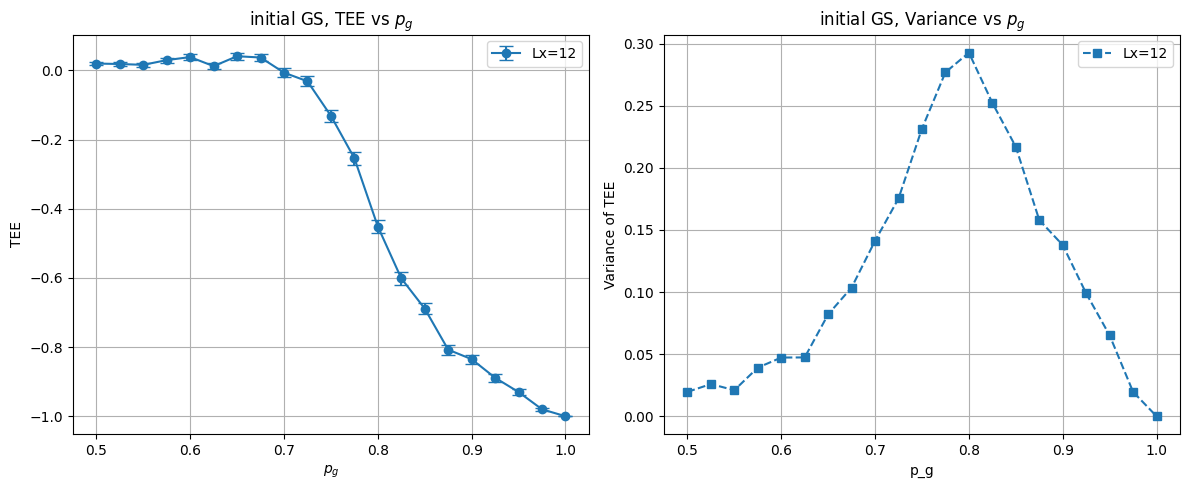

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import glob


cmap = plt.colormaps['gnuplot']
# npzファイルのパターン。Lxの値が変わる場合にマッチさせる
#files = glob.glob("Lx_*_MPI_results.npz")
files = glob.glob("px_0.0_Lx_*_MPI_results.npz")
print("見つかったファイル:", files)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for file in files:
    data = np.load(file)
    # ファイル名からLxの値を抽出 (例: Lx_12_MPI_results.npz → 12)
    Lx_str = file.split("_")[3]  # '12'の部分
    Lx = int(Lx_str)
    #Lx_str = file.split("_")[1]  # '12'の部分
    #Lx = Lx_str

    pg = data['pg']
    TEE_ave = data['TEE_ave']
    TEE_err = data['TEE_err']
    TEE_var = data['TEE_var']

    data.close()

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err,fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)
    print(pg)

ax[0].set_xlabel('$p_g$')
ax[0].set_ylabel('TEE')
ax[0].set_title('initial GS, TEE vs $p_g$')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('p_g')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('initial GS, Variance vs $p_g$')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig("px_0.0"+"_Lx_"+"{:}".format(Lx)+"_MPI_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
import copy
from numba import njit,c16,i8,u2
import sys
import math
from mpi4py import MPI

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

#seed = int(time.time()) + rank * 10000
#np.random.seed(seed)
global_seed = 123456  # 一貫性を持たせるため任意の定数
seed = global_seed + rank
np.random.seed(seed)

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

time_start = time.time()

def idx(x,y,Lx,Ly):
    return (x % Lx) + Lx * (y % Ly)
def inv_idx(i,Lx,Ly):
    return i % Lx, i // Lx


def dir_x(x,y,Lx,Lv):
    return x+Lx*y
def dir_y(x,y,Lx,Lv):
    return x+Lx*y+Lv
def dir_xy(x,y,Lx,Lv):
    return x+Lx*y+2*Lv


def create_transformation_pv_link(Lv, Lx, Ly):
    #############################################
    ############ plaquette part #################
    #############################################
    p_indd = np.zeros((2*Lx*Ly,3),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            #下三角
            ic=(ix%Lx)+Lx*(iy%Ly)
            ipx=(ix+1)%Lx
            ipy=(iy+1)%Ly
            p_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            p_indd[ic][1]=dir_y(ipx,iy,Lx,Lv)
            p_indd[ic][2]=dir_xy(ix,iy,Lx,Lv)
            #上三角
            p_indd[ic+Lx*Ly][0]=dir_xy(ix,iy,Lx,Lv)
            p_indd[ic+Lx*Ly][1]=dir_x(ix,ipy,Lx,Lv)
            p_indd[ic+Lx*Ly][2]=dir_y(ix,iy,Lx,Lv)

    ############################################
    ############ vertex part ###################
    ############################################
    v_indd = np.zeros((Lx*Ly,6),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            ic=(ix%Lx)+Lx*(iy%Ly)
            imx=(ix-1)%Lx
            imy=(iy-1)%Ly
            v_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            v_indd[ic][1]=dir_xy(ix,iy,Lx,Lv)
            v_indd[ic][2]=dir_y(ix,iy,Lx,Lv)
            v_indd[ic][3]=dir_x(imx,iy,Lx,Lv)
            v_indd[ic][4]=dir_xy(imx,imy,Lx,Lv)
            v_indd[ic][5]=dir_y(ix,imy,Lx,Lv)
    #print(v_indd)
    #print(p_indd)
    return p_indd, v_indd


####################################################
def initial_stabilizer_state(case,Ld,Lxd,Lyd,v_ind,p_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld),dtype='uint32')
    if case == 1:
        #Case I: X product state
        for ii in range(Ld):
            MRi[ii][ii]=1 # X
    if case == 2:
        #Case I: Z product state
        for ii in range(Ld):
            MRi[ii][Ld+ii]=1 # Z
    if case ==3:
        ##Case III: unique g.s. of TC 
        ### plaquette stabilizers ZZZ ###
        for ip in range(2*Lxd*Lyd-1):
            MRi[ip][Ld+p_ind[ip][0]]=1 # Z0
            MRi[ip][Ld+p_ind[ip][1]]=1 # Z1
            MRi[ip][Ld+p_ind[ip][2]]=1 # Z2
            #独立ではない最後のBpだけ取らない
        ### vertex stabilizers  XXXXXX ###
        for iv in range((Lxd)*(Lyd)-1):
            ivs=iv+2*Lxd*Lyd-1  # note that iv and ivs are different.
            MRi[ivs][v_ind[iv][0]]=1 # X0
            MRi[ivs][v_ind[iv][1]]=1 # X1
            MRi[ivs][v_ind[iv][2]]=1 # X2
            MRi[ivs][v_ind[iv][3]]=1 # X3
            MRi[ivs][v_ind[iv][4]]=1 # X4
            MRi[ivs][v_ind[iv][5]]=1 # X5
            #独立ではない最後のAvだけ取らない
        ### Add logical operators###
            # x-direction loop logical Z
            for kk in range(Lx):
                iv=(kk%Lx)+Lx*(0%Ly)
                MRi[Ld-2][Ld+v_ind[iv][0]]=0 #Z
            # x-direction loop logical Z
            for kk in range(Ly):
                iv=(0%Lx)+Lx*(kk%Ly)
                MRi[Ld-1][Ld+v_ind[iv][1]]=0 #Z
    #print(MRi)
    return MRi

####################################################
def measurement_op(dMR,Ld,Lxd,Lyd,v_ind,p_ind,Gcd,mtyped):
    Meo=np.zeros(2*Ld,dtype='uint32')
    #
    if mtyped==1: #plaquette or star operator
        todo=[0,1]
        prob_list = [0.5,0.5]
        vorp = np.random.choice(todo,size=None,replace=True, p=prob_list)
        if vorp==0:
            todo=np.arange(Lxd*Lyd)
            vp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[v_ind[vp][0]]=1 #X0
            Meo[v_ind[vp][1]]=1 #X1
            Meo[v_ind[vp][2]]=1 #X2
            Meo[v_ind[vp][3]]=1 #X3
            Meo[v_ind[vp][4]]=1 #X4
            Meo[v_ind[vp][5]]=1 #X5
        else:
            todo=np.arange(2*Lxd*Lyd)
            pp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[Ld+p_ind[pp][0]]=1 #Z0
            Meo[Ld+p_ind[pp][1]]=1 #Z1
            Meo[Ld+p_ind[pp][2]]=1 #Z2
            
    if mtyped==2: #local X
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[mp]=1 #X0
        
    if mtyped==3: #local Z
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[Ld+mp]=1 #X0
    
    # Meo without outcome sign
    MeoF=np.zeros(2*Ld,dtype='uint32')
    MeoF=Meo
    
    # dMR without foctor
    dMRF=np.zeros((Ld,2*Ld),dtype='uint32')
    dMRF=dMR
    #check anti commtation
    Mgs=np.dot(dMRF,np.dot(Gcd,MeoF.T))
    Mgs=Mgs%2  ## check: reduce Z2 value 
    
    antic_index_list=[]
    aid=np.where(Mgs[:]!=0)
    antic_index_list=aid[0]
    #######
    lenMe=len(antic_index_list)
    if lenMe !=0:
        kc=antic_index_list[0]
        dMR_prev=dMR[kc].copy()
        #replace stabilizer for kc
        dMR[kc]=Meo
        update_list=np.delete(antic_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
    return dMR

def subset2(Ld,Ax,Ay,Lx,Ly,p_indd):
    i = idx(Ax,Ay,Lx,Ly)
    Asub_set = set()
    for j in range(3):
        Asub_set.add(p_indd[i][j]) #三角形
        Asub_set.add(p_indd[i + Lx*Ly][j]) #逆三角形
        print(p_indd[i][j])
        print(p_indd[i + Lx*Ly][j])
    return Asub_set

def subset6(Ld,Ax,Ay,Lx,Ly,p_indd):
    Asub_set = set()
    Amx=(Ax - 1) % Lx
    Amy=(Ay - 1) % Ly
    i0 = idx(Ax,Ay,Lx,Ly)
    i1 = idx(Amx,Amy,Lx,Ly)
    i2 = idx(Amx,Ay,Lx,Ly)
    i3 = idx(Ax,Amy,Lx,Ly)
    for j in range(3):
        Asub_set.add(p_indd[i0][j])
        Asub_set.add(p_indd[i0 + Lx*Ly][j])
        Asub_set.add(p_indd[i1][j])
        Asub_set.add(p_indd[i1 + Lx*Ly][j])
        Asub_set.add(p_indd[i2][j])
        Asub_set.add(p_indd[i3+Lx*Ly][j])
    return Asub_set

# https://arxiv.org/abs/2204.08489
def EE_cal(MRd,Asub_set,Ld):
    # partition #
    #LA=Ld//2
    Asub=list(Asub_set)
    LA=len(Asub)
    MRdA=np.zeros((Ld,2*(len(Asub))),dtype='uint32')
    #print("new",Asub)
    for k2 in range(len(Asub)):
        MRdA[:,k2]=MRd[:,Asub[k2]].copy()
        MRdA[:,(LA)+k2]=MRd[:,(Ld)+Asub[k2]].copy()
    #print(MRdA.shape)
    #print(MRdA)
    rankA=rank_mod2_v3(MRdA)
    #print(rankA)
    EEd=rankA-(LA)
    return EEd

#############################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i
############################

#case1= X,case2= Z, case3= ground state of TC
case=1


fig, ax = plt.subplots(1,2,figsize=(12,4))

data_set = {}
#L_list=[10,12,14,16]
L_list=[10,12]
Np=6
Nd = 50 #800 sample number

# --- 1. 計算タスクの全リスト作成 ---
tasks = []
for tmp_i, Lx in enumerate(L_list):
    Ly = Lx
    for ip in range(Np):
        for ids in range(Nd):
            tasks.append((tmp_i, ip, ids))

# --- 2. MPI rankに均等割り当て ---
my_tasks = [tasks[i] for i in range(len(tasks)) if i % size == rank]

# --- 3. 計算結果をためる辞書 ---
local_results = {}  # key = (Lx, pg), value = [TEE値のリスト]


for (tmp_i, ip, ids) in my_tasks:
    
    Lx=L_list[tmp_i]
    Ly=L_list[tmp_i]

    Lv=Lx*Ly # total # of vertex
    L=3*Lv # total # of link qubits
    Lp=2*Lv  # total # of plaquette
    NT=6*L #4*Lでなくて6*L?? total time step
    
    p_indd, v_indd=create_transformation_pv_link(Lv, Lx, Ly)

    p_list=[]
    TEE_ave=[]
    TEE_error=[]
    TEE_var=[]

    #for ip in range(len(p_list)):
    ps=0.5 # ps < pg < 1
    px=0.0
    #pg=0.5*(1-px)*ip/(Np-1)+0.5
    pg=ps+(1-px-ps)*ip/(Np-1)
    pz=1-px-pg
    p_list=np.append(p_list,pg)
    # stabilizer matrix
    MR0=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix
    # sample set of physical quantity
    MR=initial_stabilizer_state(case,L,Lx,Ly,v_indd,p_indd)

    ### check matrix ###
    Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
    for k in range(L):
        Gc[k][L+k]=1
        Gc[L+k][k]=1  
    Gc_csr=csr_matrix(Gc)
    
    TEE_list=[]
    #MR=MR0 #-0.85
    #MR = np.copy(MR0) #-0.86
    #MR =copy.deepcopy(MR0) #-0.85
    #measurement dynamics

    prob_list=[pg,px,pz]
    todo=[1,2,3]
    for it in range(NT):
        mtype= np.random.choice(todo,size=None,replace=True,p=prob_list)
        MR=measurement_op(MR,L,Lx,Ly,v_indd,p_indd,Gc,mtype)
        if it==NT-1:
            Ax,Ay=Lx//2,Ly//2
            Bx,By=Ax-2,Ay-1
            Cx,Cy=Ax-1,Ay-2     

            A = subset6(L,Ax,Ay,Lx,Ly,p_indd)
            B = subset6(L,Bx,By,Lx,Ly,p_indd) - A
            C = subset6(L,Cx,Cy,Lx,Ly,p_indd) - A -B
            AB= A|B
            BC= B|C
            CA= C|A
            ABC=AB|C
            
            SA=EE_cal(MR,A,L)
            SB=EE_cal(MR,B,L)
            SC=EE_cal(MR,C,L)
            SAB=EE_cal(MR,AB,L)
            SBC=EE_cal(MR,BC,L)
            SCA=EE_cal(MR,CA,L)
            SABC=EE_cal(MR,ABC,L)

            TEE=SA+SB+SC-SAB-SBC-SCA+SABC
            print(f"rank={rank:>2} Lx=Ly={Lx:>2} pg={pg:>6.3f} ids={ids:>4} TEE={TEE}", flush=True)
            TEE_list=np.append(TEE_list,TEE)
            """if len(TEE_list) > 1:
                TEE_aved = np.mean(TEE_list)
                TEE_vard = np.var(TEE_list)
                TEE_errord = np.std(TEE_list, ddof=1) / np.sqrt(len(TEE_list))
            elif len(TEE_list) == 1:
                TEE_aved = TEE_list[0]
                TEE_vard = 0.0
                TEE_errord = 0.0
            else:
                TEE_aved = np.nan
                TEE_vard = np.nan
                TEE_errord = np.nan"""

    key = (Lx, round(pg, 3))
    if key not in local_results:
        local_results[key] = []
    local_results[key].append(TEE)

# --- 4. MPI集約 ---

all_results = comm.gather(local_results, root=0)

if rank == 0:
    merged_results = {}
    for res in all_results:
        for key, val_list in res.items():
            if key not in merged_results:
                merged_results[key] = []
            merged_results[key].extend(val_list)

    # Lxごとにまとめて結果計算・表示・保存
    data_set = {}
    for key in merged_results:
        Lx, pg = key
        vals = merged_results[key]
        ave = np.mean(vals)
        err = np.std(vals, ddof=1)/np.sqrt(len(vals)) if len(vals) > 1 else 0.0
        var = np.var(vals)
        print(f"Lx={Lx}, pg={pg:.3f} : ave={ave:.4f} ± {err:.4f}, var={var:.4f}")
        data_set.setdefault(Lx, {}).setdefault("pg", []).append(pg)
        data_set[Lx].setdefault("TEE_ave", []).append(ave)
        data_set[Lx].setdefault("TEE_err", []).append(err)
        data_set[Lx].setdefault("TEE_var", []).append(var)

    # np.savez で Lxごとにファイル保存例
    for Lx in data_set:
        np.savez_compressed(f"px_{px}_Lx_{Lx}_MPI_results.npz", 
                            pg=data_set[Lx]["pg"],
                            TEE_ave=data_set[Lx]["TEE_ave"],
                            TEE_err=data_set[Lx]["TEE_err"],
                            TEE_var=data_set[Lx]["TEE_var"])

    # 必要ならグラフ描画もここで可能
    time_end = time.time()
    print("px=",px,"Np=",Np,"Nd=",Nd,"NT=",NT,"time=",int(time_end-time_start))

    ax[0].set_xlabel(r'$p_g$',fontsize=16)  # x軸ラベル
    ax[0].set_ylabel(r'TEE',fontsize=16)  # y軸ラベル
    ax[0].set_title('initial product X pg+pz=1')
    ax[0].errorbar(p_list,TEE_ave,yerr=TEE_error, marker='x', capthick=1, capsize=8, lw=1,label='Lx=Ly='+"{:}".format(Lx))
    ax[0].legend(loc=0,fontsize=14)    # 凡例
    ax[1].set_xlabel(r'$p_g$',fontsize=16)  # x軸ラベル
    ax[1].set_ylabel(r'$var[TEE]$',fontsize=16)  # y軸ラベル
    ax[1].set_title('initial product X pg+pz=1')
    ax[1].plot(p_list,TEE_var,'x',linestyle='dashed',label='Lx=Ly='+"{:}".format(Lx))
    ax[1].legend(loc=0,fontsize=14)    # 凡例
    np.savez_compressed("px_"+"{:}".format(px)+"_Lx_"+"{:}".format(Lx)+".npz", **data_set)
fig.tight_layout()  # レイアウトの設定
plt.savefig("px_"+"{:}".format(px)+"_Lx_"+"{:}".format(Lx)+".png", dpi=300, bbox_inches='tight')
plt.show()


    







In [11]:
import numpy as np

data = np.load("px_0.0_Lx_16_MPI_results.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[ 0.04  0.02  0.04 -0.06 -0.02 -0.28 -0.22 -0.7  -0.88 -0.98 -1.  ]
[0.02799417 0.02       0.02799417 0.03392669 0.04508495 0.07580857
 0.07165678 0.06546537 0.05451081 0.02       0.        ]
[0.0384 0.0196 0.0384 0.0564 0.0996 0.2816 0.2516 0.21   0.1456 0.0196
 0.    ]


In [8]:
import numpy as np

data = np.load("px_0.0_Lx_12_MPI_results.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var']


見つかったファイル: ['px_0.0_Lx_14_MPI_results.npz', 'px_0.0_Lx_10_MPI_results.npz', 'px_0.0_Lx_16_MPI_results.npz', 'px_0.0_Lx_12_MPI_results.npz']
px_0.0_Lx_10_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
px_0.0_Lx_12_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
px_0.0_Lx_14_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
px_0.0_Lx_16_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]


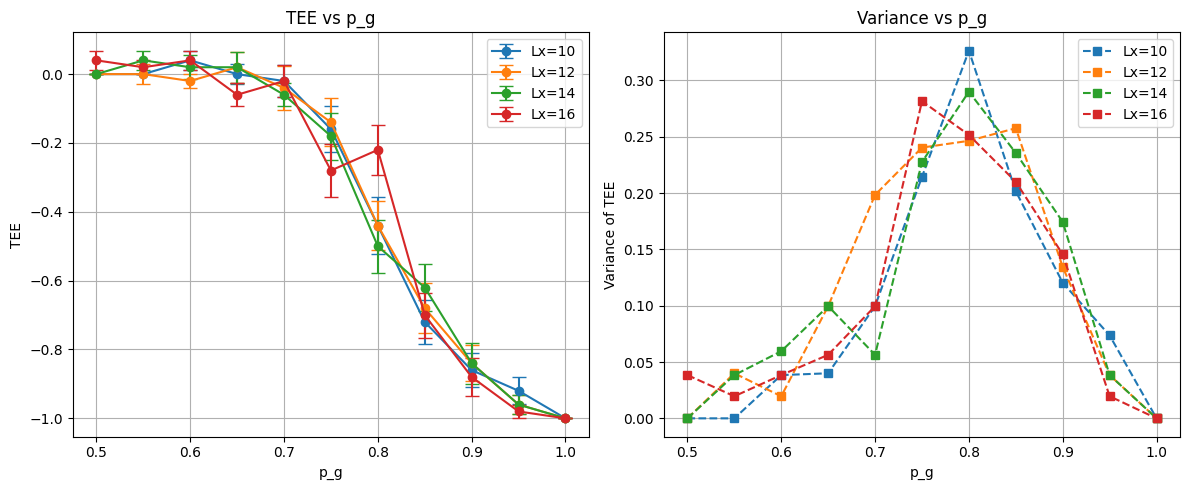

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

cmap = plt.colormaps['gnuplot']

# ファイル読み込み（Lxの数字を含むもの）
files = glob.glob("px_0.0_Lx_*_MPI_results.npz")
print("見つかったファイル:", files)

# --- Lxの数値でソート ---
lx_file_pairs = []
for file in files:
    match = re.search(r'Lx_(\d+)', file)
    if match:
        Lx = int(match.group(1))
        lx_file_pairs.append((Lx, file))
    else:
        print(f"Lxの抽出失敗: {file}")

# 数値順に並べ替え（10, 12, 14, 16...）
lx_file_pairs.sort(key=lambda x: x[0])

# プロット用
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for Lx, file in lx_file_pairs:
    with np.load(file) as data:
        pg = data['pg']
        TEE_ave = data['TEE_ave']
        TEE_err = data['TEE_err']
        TEE_var = data['TEE_var']

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)
    print(f"{file}: pg = {pg}")

# 描画設定
ax[0].set_xlabel('p_g')
ax[0].set_ylabel('TEE')
ax[0].set_title('TEE vs p_g')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('p_g')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('Variance vs p_g')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()
